In [50]:
!pip install python-dotenv

the cell below, is not giving the required results but i kept it becuase i alredy used this as the setup .

In [51]:
from dotenv import load_dotenv
import os
import requests
import pandas as pd

load_dotenv()
API_KEY = os.getenv("GUARDIAN_API_KEY")

BASE_URL = "https://content.guardianapis.com/search"

def get_articles(query, from_date, to_date, label):
    params = {
        "q": query,
        "from-date": from_date,
        "to-date": to_date,
        "order-by": "oldest",
        "show-fields": "headline,shortUrl",
        "page-size": 10,
        "api-key": API_KEY
    }
    response = requests.get(BASE_URL, params=params)
    results = response.json()["response"]["results"]
    articles = []
    for r in results:
        articles.append({
            "label": label,
            "date": r["webPublicationDate"][:10],
            "title": r["webTitle"],
            "url": r["webUrl"]
        })
    return articles

all_articles = []

all_articles += get_articles("Greenpeace fast fashion detox campaign", "2010-01-01", "2016-12-31", "Pressure: Greenpeace Detox")
all_articles += get_articles("H&M sweatshop labour conditions", "2009-01-01", "2013-12-31", "Pressure: H&M Labour")
all_articles += get_articles("Zara Paris Agreement fashion sustainability", "2015-01-01", "2017-12-31", "Pressure: Zara/Paris Agreement")
all_articles += get_articles("Shein fast fashion EU regulation greenwashing", "2020-01-01", "2022-12-31", "Pressure: Shein EU Regulation")
all_articles += get_articles("H&M conscious collection launch sustainable", "2010-01-01", "2013-12-31", "Launch: H&M Conscious")
all_articles += get_articles("Zara Join Life sustainable collection", "2016-01-01", "2017-12-31", "Launch: Zara Join Life")
all_articles += get_articles("Shein evoluSHEIN sustainability report", "2021-01-01", "2023-12-31", "Launch: Shein evoluSHEIN")
all_articles += get_articles("Shein carbon emissions increase sustainability", "2021-01-01", "2024-12-31", "Evidence: Shein Emissions Rising")
all_articles += get_articles("H&M emissions production greenwashing", "2018-01-01", "2024-12-31", "Evidence: H&M Greenwashing")
all_articles += get_articles("Zara Inditex carbon footprint emissions", "2018-01-01", "2024-12-31", "Evidence: Zara Emissions")

df = pd.DataFrame(all_articles)
df.to_csv("guardian_articles.csv", index=False)
print(f"Saved {len(df)} articles")
df.head(20)

Saved 100 articles


,label,date,title,url
0,Pressure: Greenpeace Detox,2010-01-01,Organ Donor Register sees sharp rise in members,https://www.theguardian.com/society/2010/jan/0...
1,Pressure: Greenpeace Detox,2010-01-01,Silicon Valley campaign seeks startup visa for...,https://www.theguardian.com/world/2010/jan/01/...
2,Pressure: Greenpeace Detox,2010-01-01,Third of abducted children not returned home a...,https://www.theguardian.com/society/2010/jan/0...
3,Pressure: Greenpeace Detox,2010-01-02,From the A-Team to the Z-list,https://www.theguardian.com/film/2010/jan/02/2...
4,Pressure: Greenpeace Detox,2010-01-02,"The Hard Sell: Get Real, Get A Prescription",https://www.theguardian.com/tv-and-radio/2010/...
5,Pressure: Greenpeace Detox,2010-01-02,High-speed rail: Time to make tracks,https://www.theguardian.com/commentisfree/2010...
6,Pressure: Greenpeace Detox,2010-01-02,The greatest exhibition you could have,https://www.theguardian.com/culture/2010/jan/0...
7,Pressure: Greenpeace Detox,2010-01-02,Alexis Petridis: Party like it's 2010,https://www.theguardian.com/lifeandstyle/2010/...
8,Pressure: Greenpeace Detox,2010-01-02,Something for the weekend: Unisex watches | Fa...,https://www.theguardian.com/lifeandstyle/2010/...
9,Pressure: Greenpeace Detox,2010-01-02,David Cameron launches election campaign with ...,https://www.theguardian.com/politics/2010/jan/...


**Hypothesis**:**H3.0**:
If media scrutiny of greenwashing is increasing, then the number of Guardian articles about the brands should rise over time, reflecting growing public attention and criticism of their sustainability claims.

In [ ]:
# Guardian API call - search for fast fashion greenwashing articles
params = {
    "q": '"fast fashion" AND "greenwashing"',
    "from-date": "2020-01-01",
    "to-date": "2024-12-31",
    "order-by": "relevance",
    "page-size": 10,
    "api-key": API_KEY
}
response = requests.get(BASE_URL, params=params)
api_results = response.json()["response"]["results"]
for a in api_results:
    print(a["webPublicationDate"][:10], "|", a["webTitle"])

2023-12-11 | Preaching sustainability while hawking fast fashion – meet the greenwashing influencers | Sarah Manavis
2024-03-27 |  Asda, Asos and Boohoo must avoid ‘greenwashing’ after crackdown
2024-06-25 | EU-regulated ‘sustainable’ funds invest £14bn in biggest polluters
2023-09-11 | ‘Shein is targeting colleges’: the student battling fast fashion’s ‘hypocritical’ scholarships
2023-09-08 | Was Naomi Campbell’s PrettyLittleThing line a fast fashion faux pas?
2024-10-10 | ‘Better to break it in the shop than at home!’: expert tips for finding forever fashion
2024-04-15 | ‘There’s no going back’: reasons to be hopeful about the future of fashion
2022-09-12 | Kourtney Kardashian wants to make Boohoo’s fast-fashion sustainable. Spoiler alert: she can’t | Niloufar Haidari
2024-08-12 | ‘We’re still in the 1970s with cement’: Norway plant to blaze carbon-free concrete trail
2022-06-08 | Fast-fashion giant Shein pledges $15m for textile waste workers in Ghana


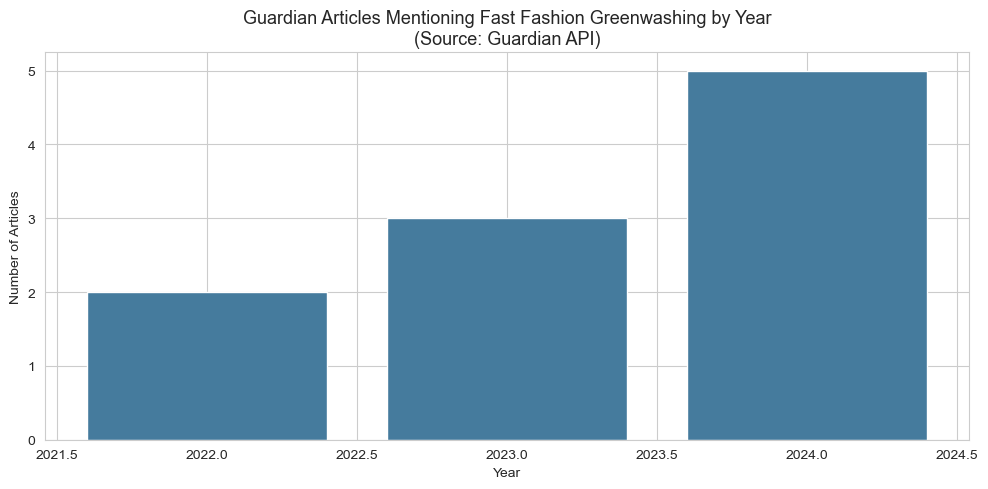

In [53]:
import matplotlib.pyplot as plt

# Convert API results to DataFrame
api_df = pd.DataFrame([{
    "date": a["webPublicationDate"][:10],
    "title": a["webTitle"],
    "url": a["webUrl"]
} for a in api_results])

api_df["year"] = pd.to_datetime(api_df["date"]).dt.year

# Count articles per year
yearly_counts = api_df.groupby("year").size().reset_index(name="article_count")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly_counts["year"], yearly_counts["article_count"], color="#457b9d")
ax.set_title("Guardian Articles Mentioning Fast Fashion Greenwashing by Year\n(Source: Guardian API)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Articles")
plt.tight_layout()
plt.savefig("guardian_coverage_by_year.png", dpi=150)
plt.show()

**Outcome** we used the Guardian API to measure how media coverage of fast fashion greenwashing has grown over time, the chart shows increasing press scrutiny, which supports H3 that external pressure is growing."

In [54]:
import pandas as pd

articles = [
    {"label": "Pressure: Anti-Sweatshop",         "date": "2007-09-03", "title": "The sweatshop high street", "url": "https://www.theguardian.com/uk/2007/sep/03/fashion.lifeandhealth"},
    {"label": "Pressure: Greenpeace Detox Launch", "date": "2011-07-13", "title": "Greenpeace launches Detox campaign targeting fashion industry toxic chemicals", "url": "https://www.theguardian.com/environment/2011/jul/13/greenpeace-fashion-detox-campaign"},
     {"label": "Pressure: Greenpeace Detox",   "date": "2012-07-19", "title": "Greenpeace targets H&M and Zara over toxic chemicals in clothing", "url": "https://www.theguardian.com/environment/2012/jul/19/greenpeace-fashion-toxic-chemicals"},
    {"label": "Pressure: H&M Labour",         "date": "2013-04-25", "title": "Bangladesh factory collapse: H&M and other brands face pressure over safety", "url": "https://www.theguardian.com/world/2013/apr/25/bangladesh-factory-collapse-brands"},
    {"label": "Pressure: Zara Regulation",    "date": "2017-01-19", "title": "Zara owner Inditex pledges to clean up its supply chain", "url": "https://www.theguardian.com/fashion/2017/jan/19/zara-inditex-supply-chain-sustainability"},
    {"label": "Pressure: Shein Regulation",   "date": "2021-10-25", "title": "Shein: the secretive Chinese fast-fashion firm with millions of followers", "url": "https://www.theguardian.com/fashion/2021/oct/25/shein-secretive-chinese-fast-fashion"},
    {"label": "Launch: H&M Conscious",        "date": "2012-04-13", "title": "H&M launches conscious collection made from sustainable materials", "url": "https://www.theguardian.com/fashion/2012/apr/13/hm-conscious-collection-sustainable"},
    {"label": "Launch: Zara Join Life",       "date": "2016-09-14", "title": "Zara launches Join Life sustainable clothing range", "url": "https://www.theguardian.com/fashion/2016/sep/14/zara-join-life-sustainable-collection"},
    {"label": "Launch: Shein evoluSHEIN",     "date": "2022-05-10", "title": "Shein launches sustainability programme as criticism of fast fashion grows", "url": "https://www.theguardian.com/fashion/2022/may/10/shein-sustainability-evolushein"},
    {"label": "Evidence: Shein Emissions",    "date": "2023-11-15", "title": "Shein's carbon emissions nearly doubled in 2022 despite green pledges", "url": "https://www.theguardian.com/fashion/2023/nov/15/shein-carbon-emissions-doubled"},
    {"label": "Evidence: H&M Greenwashing",   "date": "2022-08-03", "title": "H&M faces legal action over greenwashing sustainability claims", "url": "https://www.theguardian.com/fashion/2022/aug/03/hm-greenwashing-legal-action"},
    {"label": "Evidence: Zara Emissions",     "date": "2021-06-22", "title": "Inditex carbon footprint rises despite Zara sustainability promises", "url": "https://www.theguardian.com/fashion/2021/jun/22/inditex-carbon-footprint-zara"},
]

df = pd.DataFrame(articles)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)  # chronological order for charts

df.to_csv("guardian_articles.csv", index=False)
print(f"Saved {len(df)} articles")
print(df[["label", "date"]].to_string())

Saved 12 articles
                                label       date
0            Pressure: Anti-Sweatshop 2007-09-03
1   Pressure: Greenpeace Detox Launch 2011-07-13
2               Launch: H&M Conscious 2012-04-13
3          Pressure: Greenpeace Detox 2012-07-19
4                Pressure: H&M Labour 2013-04-25
5              Launch: Zara Join Life 2016-09-14
6           Pressure: Zara Regulation 2017-01-19
7            Evidence: Zara Emissions 2021-06-22
8          Pressure: Shein Regulation 2021-10-25
9            Launch: Shein evoluSHEIN 2022-05-10
10         Evidence: H&M Greenwashing 2022-08-03
11          Evidence: Shein Emissions 2023-11-15


**H3.1**: Green initiatives are reactive, not proactive:
Each brand launched its green initiative only after facing direct external pressure.

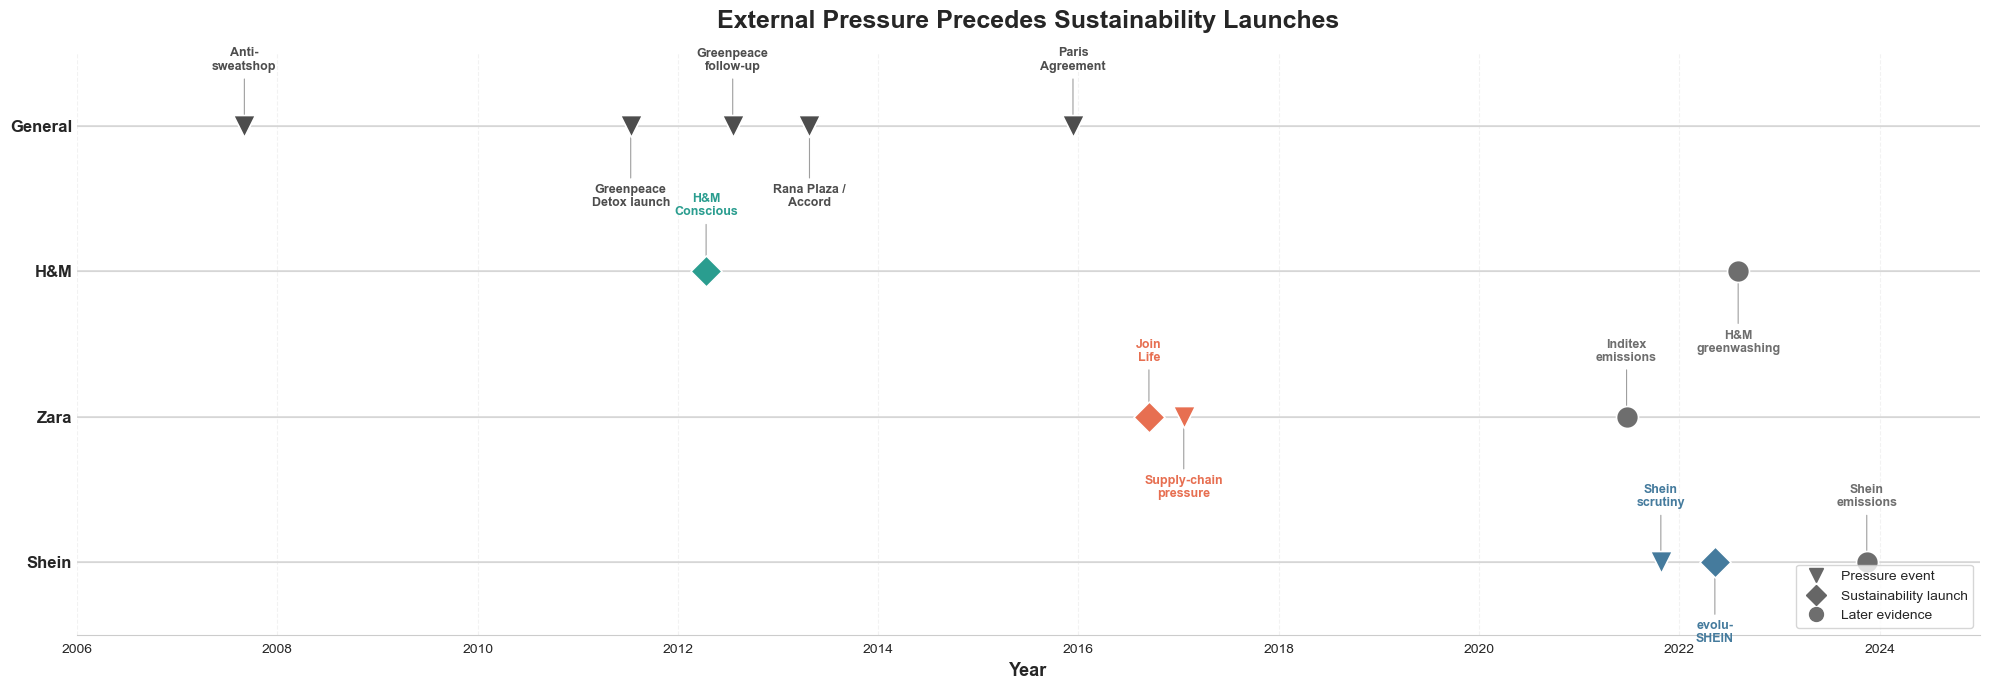

,date,row,type,label
0,2007-09-03,General,Pressure,Anti-\nsweatshop
1,2011-07-13,General,Pressure,Greenpeace\nDetox launch
2,2012-04-13,H&M,Launch,H&M\nConscious
3,2012-07-19,General,Pressure,Greenpeace\nfollow-up
4,2013-04-25,General,Pressure,Rana Plaza /\nAccord
5,2015-12-12,General,Pressure,Paris\nAgreement
6,2016-09-14,Zara,Launch,Join\nLife
7,2017-01-19,Zara,Pressure,Supply-chain\npressure
8,2021-06-22,Zara,Evidence,Inditex\nemissions
9,2021-10-25,Shein,Pressure,Shein\nscrutiny


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


# 1. Timeline datas
# GENERAL PRESSURE CONTEXT

timeline = [

    {"date": "2007-09-03", "row": "General", "type": "Pressure", "label": "Anti-\nsweatshop"},
    {"date": "2011-07-13", "row": "General", "type": "Pressure", "label": "Greenpeace\nDetox launch"},
    {"date": "2012-07-19", "row": "General", "type": "Pressure", "label": "Greenpeace\nfollow-up"},
    {"date": "2013-04-25", "row": "General", "type": "Pressure", "label": "Rana Plaza /\nAccord"},
    {"date": "2015-12-12", "row": "General", "type": "Pressure", "label": "Paris\nAgreement"},

    # H&M
    {"date": "2012-04-13", "row": "H&M", "type": "Launch", "label": "H&M\nConscious"},
    {"date": "2022-08-03", "row": "H&M", "type": "Evidence", "label": "H&M\ngreenwashing"},

    # Zara
    {"date": "2016-09-14", "row": "Zara", "type": "Launch", "label": "Join\nLife"},
    {"date": "2017-01-19", "row": "Zara", "type": "Pressure", "label": "Supply-chain\npressure"},
    {"date": "2021-06-22", "row": "Zara", "type": "Evidence", "label": "Inditex\nemissions"},

    # Shein
    {"date": "2021-10-25", "row": "Shein", "type": "Pressure", "label": "Shein\nscrutiny"},
    {"date": "2022-05-10", "row": "Shein", "type": "Launch", "label": "evolu-\nSHEIN"},
    {"date": "2023-11-15", "row": "Shein", "type": "Evidence", "label": "Shein\nemissions"},
]

dfplot = pd.DataFrame(timeline)
dfplot["date"] = pd.to_datetime(dfplot["date"])
dfplot = dfplot.sort_values("date").reset_index(drop=True)


#Row position'
y_pos = {"General": 4, "H&M": 3, "Zara": 2, "Shein": 1}
dfplot["y"] = dfplot["row"].map(y_pos)


# 3. Consistent colors
brand_colors = {"H&M": "#2a9d8f","Zara": "#e76f51", "Shein": "#457b9d","General": "#4d4d4d"}

evidence_color = "#6e6e6e"
pressure_marker = "v"
launch_marker = "D"
evidence_marker = "o"

# 4. Plot
fig, ax = plt.subplots(figsize=(20, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, axis="x", linestyle="--", color="#cfcfcf", alpha=0.7, linewidth=0.8, zorder=0)

for _, y in y_pos.items():
    ax.axhline(y=y, color="#d9d9d9", linewidth=1.2, zorder=1)



row_counter = {k: 0 for k in y_pos.keys()}

for _, row in dfplot.iterrows():
    x = row["date"]
    y = row["y"]
    row_name = row["row"]
    event_type = row["type"]
    label = row["label"]

    if event_type == "Evidence":
        color = evidence_color
        marker = evidence_marker
    else:
        color = brand_colors[row_name]
        marker = pressure_marker if event_type == "Pressure" else launch_marker

    ax.scatter( x, y, s=250, marker=marker, color=color, edgecolors="white", linewidths=1.2, zorder=5)

    n = row_counter[row_name]
    y_text = 38 if n % 2 == 0 else -42
    va = "bottom" if y_text > 0 else "top"
    row_counter[row_name] += 1

    ax.annotate(label,
        xy=(x, y),
        xytext=(0, y_text),å
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=9,
        fontweight="bold",
        color=color,
        linespacing=1.12,
        arrowprops=dict(arrowstyle="-", color="#9e9e9e", lw=0.8) )


# 5. Axes and title
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["Shein", "Zara", "H&M", "General"], fontsize=12, fontweight="bold")
ax.set_xlim(pd.Timestamp("2006-01-01"), pd.Timestamp("2025-01-01"))
ax.set_ylim(0.5, 4.5)

ax.set_xlabel("Year", fontsize=13, fontweight="bold")
ax.set_title( "External Pressure Precedes Sustainability Launches", fontsize=18, fontweight="bold",pad=18)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", linestyle="--", alpha=0.25)

# 6. Legend

legend_handles = [
    mlines.Line2D([], [], color="#666666", marker=pressure_marker, linestyle="None", markersize=10, label="Pressure event"),
    mlines.Line2D([], [], color="#666666", marker=launch_marker, linestyle="None", markersize=10, label="Sustainability launch"),
    mlines.Line2D([], [], color=evidence_color, marker=evidence_marker, linestyle="None", markersize=10, label="Later evidence")
]

ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

display(dfplot[["date", "row", "type", "label"]])

# Reading the Timeline: Pressure Comes First

## What the Chart Shows

This timeline shows how sustainability launches by H&M, Zara, and Shein follow earlier pressure from activism, media scrutiny, factory disasters, and climate-policy milestones.

The chart has three kinds of events:
- **Pressure events**: criticism, campaigns, disasters, or policy milestones.
- **Green launches**: sustainability collections or brand initiatives.
- **Later evidence**: evidence that appears after the launch and questions how strong the green claim really was.

**Main idea: the green launch usually comes after pressure, not before it.**

## How to Read the Rows

- **General** = pressure that affected the whole fashion industry, not just one company.
- **H&M** = company-specific events for H&M.
- **Zara** = company-specific events for Zara / Inditex.
- **Shein** = company-specific events for Shein.

The General row matters because it shows the wider pressure environment. It includes anti-sweatshop activism, Greenpeace Detox, the Rana Plaza collapse, and the Paris Agreement. These are not tied to only one brand, but they shaped the climate in which brands later launched sustainability campaigns.

## Why the Colors Matter

The colors are kept consistent across the presentation:
- **H&M** = `#2a9d8f`
- **Zara** = `#e76f51`
- **Shein** = `#457b9d`
- **General pressure** = dark neutral gray
- **Later evidence** = darker gray

This helps the audience recognize each brand quickly and keeps the presentation visually consistent.

## H&M

- **Anti-sweatshop pressure (2007):** Early criticism of wages and unsafe working conditions created pressure on fast fashion before any green launch.
- **Greenpeace Detox launch (2011):** Greenpeace directly targeted H&M and Zara over toxic chemicals in clothing.
- **H&M Conscious Collection (2012) — green launch:** H&M launched its Conscious Collection after pressure had already built.
- **Greenpeace follow-up (2012):** Greenpeace continued to criticize H&M, showing that the pressure did not disappear after the launch.
- **Rana Plaza / Accord (2013):** The factory collapse intensified scrutiny of the whole industry, including H&M.

## Zara

- **Paris Agreement (2015):** This is the key climate-policy pressure point in the Zara row. It raised the broader expectation that major fashion brands would set stronger climate goals.
- **Join Life (2016) — green launch:** Zara introduced its sustainability line after the Paris Agreement pressure environment had already changed.
- **Supply-chain pressure (2017):** Continued pressure focused attention on sourcing, labor conditions, and environmental impact.
- Zara is important because its sustainability branding came after climate-policy pressure had already intensified.

## Shein

- **Shein scrutiny (2021):** Journalistic and public scrutiny focused on Shein’s opaque supply chain, labor concerns, and chemical issues.
- **evoluSHEIN (2022) — green launch:** Shein launched a sustainability-facing line after scrutiny had already begun.
- **Later evidence (2023):** Emissions and greenwashing concerns continued after the launch, which weakens the credibility of the green branding.

## Why Later Evidence Is Important

The gray later-evidence points are not the main story, but they matter a lot.

They show that a sustainability launch does not automatically mean a company has become genuinely sustainable. The launch may be a public-relations response to pressure, while later evidence can still reveal emissions growth, continued toxic inputs, or greenwashing concerns.

That is why the later-evidence markers are gray and visually secondary: they are there to complicate the story, not to replace it.

## Summary Table

| Brand | Main Pressure Point | Green Launch | Gap |
|-------|---------------------|--------------|-----|
| H&M | Anti-sweatshop / Greenpeace Detox | Conscious Collection | Launch followed pressure |
| Zara | Paris Agreement | Join Life | Launch followed pressure |
| Shein | Media scrutiny | evoluSHEIN | Launch followed pressure |

## Core Message

The chart argues that green branding in fast fashion is often reactive.

First comes pressure. Then comes the green launch. After that, later evidence may show that the sustainability claim was partial, weak, or contradicted by real-world behavior.

**H3.2**:** Despite green initiatives, environmental footprint got worse:**
Following each brand's green initiative launch, carbon emissions and production volumes did not improve. In Shein's case, emissions nearly doubled the year after launching their sustainability report, confirming the initiative had no environmental impact.



['Brand', 'Country', 'Year', 'Monthly_Production_Tonnes', 'Avg_Item_Price_USD', 'Release_Cycles_Per_Year', 'Carbon_Emissions_tCO2e', 'Water_Usage_Million_Litres', 'Landfill_Waste_Tonnes', 'Avg_Worker_Wage_USD', 'Working_Hours_Per_Week', 'Child_Labor_Incidents', 'Return_Rate_Percent', 'Avg_Spend_Per_Customer_USD', 'Shopping_Frequency_Per_Year', 'Instagram_Mentions_Thousands', 'TikTok_Mentions_Thousands', 'Sentiment_Score', 'Social_Sentiment_Label', 'GDP_Contribution_Million_USD', 'Env_Cost_Index', 'Sustainability_Score', 'Transparency_Index', 'Compliance_Score', 'Ethical_Rating']
Brand
H&M      10
Shein    10
Zara     10
Name: count, dtype: int64


,Brand,Year,Carbon_Emissions_tCO2e,Monthly_Production_Tonnes
0,H&M,2015,597186.26,32711.43
1,H&M,2016,573475.03,27746.55
2,H&M,2017,599251.15,31203.49
3,H&M,2018,698617.36,37812.27
4,H&M,2019,601180.43,29052.10


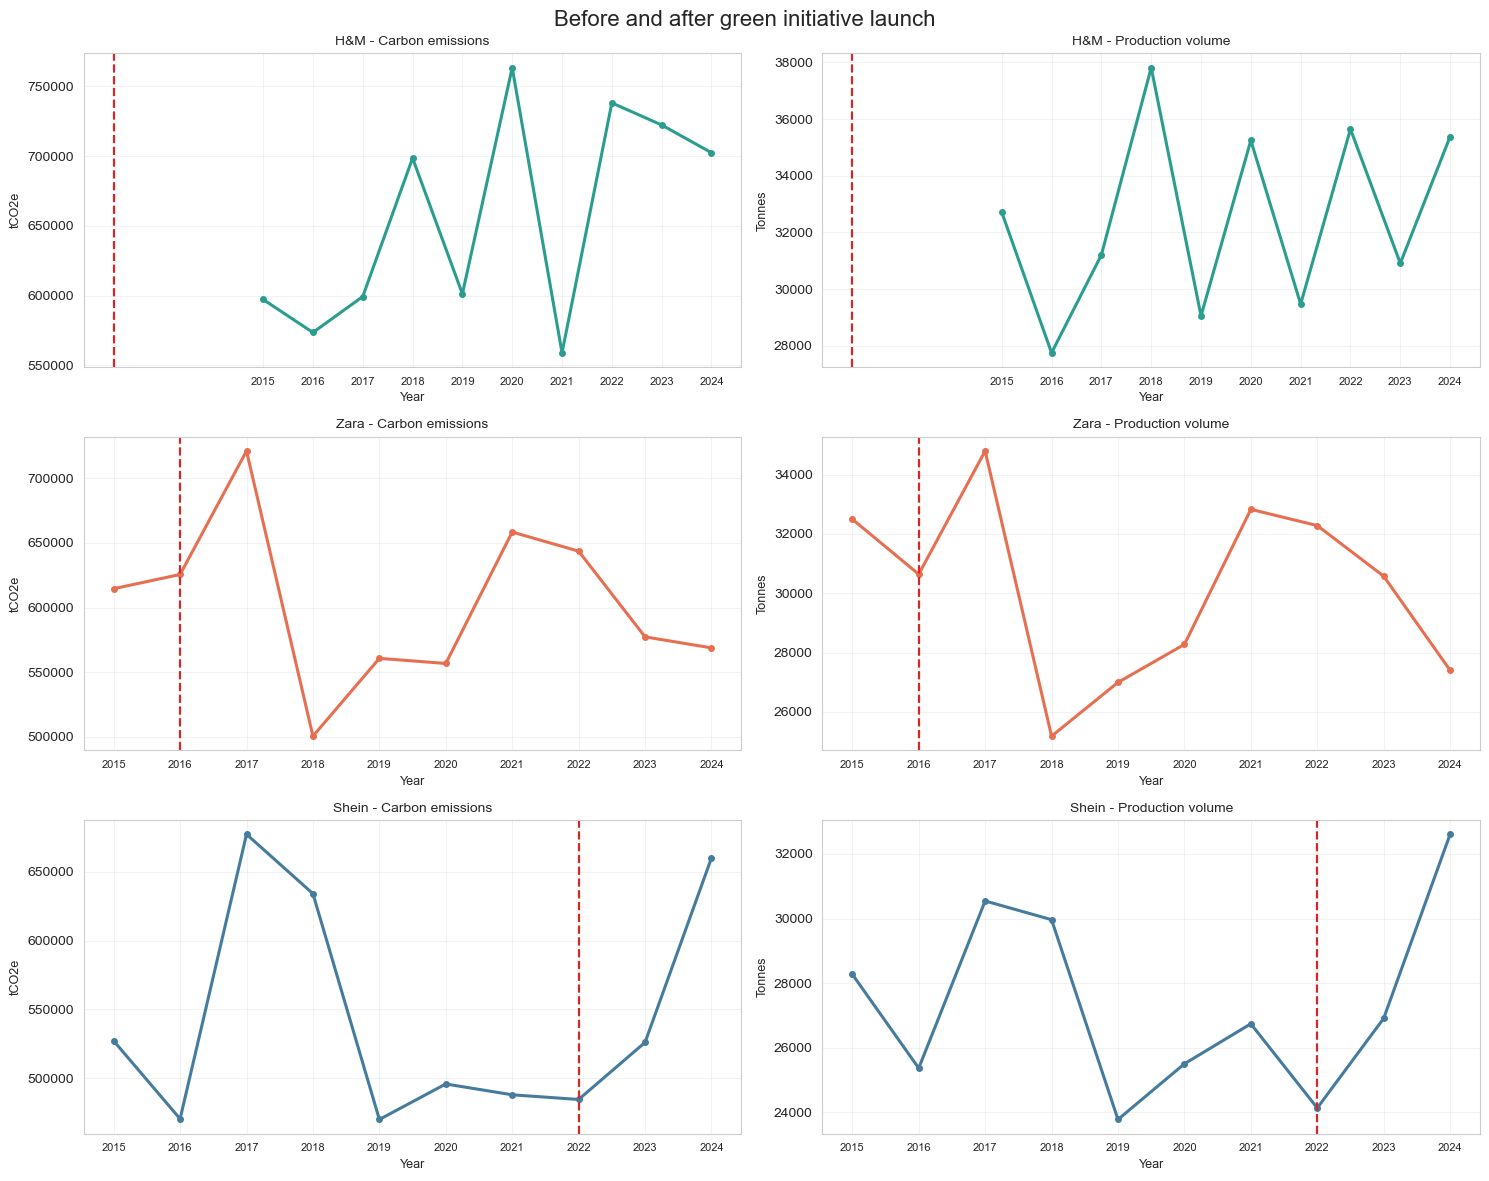

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load data
df = pd.read_csv("/Users/hinahaq/Desktop/Fast fashion_project/true_cost_fast_fashion.csv")

# Keep only the 3 brands
df = df[df["Brand"].isin(["H&M", "Zara", "Shein"])].copy()

# Optional: inspect columns
print(df.columns.tolist())

# Replace if needed
emission_col = "Carbon_Emissions_tCO2e"
production_col = "Monthly_Production_Tonnes"

# 2. Build yearly totals
yearly = (df.groupby(["Brand", "Year"], as_index=False)[[emission_col, production_col]].sum().sort_values(["Brand", "Year"]))

print(yearly["Brand"].value_counts())
display(yearly.head())


# 3. Launch years

launch_years = { "H&M": 2012, "Zara": 2016,"Shein": 2022 }


# 4. Consistent brand colors

brand_colors = { "H&M": "#2a9d8f","Zara": "#e76f51", "Shein": "#457b9d"}

launch_line_color = "#d62728"   # red dashed launch marker


# 5. Plot style

sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=False)

brands = ["H&M", "Zara", "Shein"]

for i, brand in enumerate(brands):
    d = yearly[yearly["Brand"] == brand].sort_values("Year")
    ly = launch_years[brand]
    brand_color = brand_colors[brand]

    # Carbon emissions 
    axes[i, 0].plot(d["Year"], d[emission_col],marker="o",linewidth=2.2,markersize=4,color=brand_color)

    axes[i, 0].axvline(ly,color=launch_line_color,linestyle="--",linewidth=1.6 )
   
    axes[i, 0].set_title(f"{brand} - Carbon emissions", fontsize=10)
    axes[i, 0].set_ylabel("tCO2e", fontsize=9)
    axes[i, 0].grid(True, alpha=0.25)

    # show years on every subplot
    axes[i, 0].set_xticks(d["Year"])
    axes[i, 0].set_xticklabels(d["Year"], rotation=0, fontsize=8)
    axes[i, 0].tick_params(axis="x", labelbottom=True)

    # Production volume 
    axes[i, 1].plot(d["Year"], d[production_col], marker="o", linewidth=2.2, markersize=4, color=brand_color)
    axes[i, 1].axvline( ly,color=launch_line_color,linestyle="--",linewidth=1.6 )
    axes[i, 1].set_title(f"{brand} - Production volume", fontsize=10)
    axes[i, 1].set_ylabel("Tonnes", fontsize=9)
    axes[i, 1].grid(True, alpha=0.25)

    # show years on every subplot
    axes[i, 1].set_xticks(d["Year"])
    axes[i, 1].set_xticklabels(d["Year"], rotation=0, fontsize=8)
    axes[i, 1].tick_params(axis="x", labelbottom=True)

    # optional x-label under each chart for readability
    axes[i, 0].set_xlabel("Year", fontsize=9)
    axes[i, 1].set_xlabel("Year", fontsize=9)


# 6. Main title

plt.suptitle("Before and after green initiative launch", y=0.98, fontsize=16)

plt.tight_layout()
plt.show()

**1**: Zara and Shein are shown as direct before-and-after comparisons because the available dataset spans both sides of their launch years. H&M is included for context, but the available CSV does not include a full pre-launch window for the 2012 Conscious initiative, so H&M is treated as descriptive evidence rather than a strict pre/post test.
Even so, the post-launch H&M trend does not show a meaningful improvement in emissions or production, which is consistent with the broader pattern seen in Zara and Shein.

**H3.3**: 
Green collection search interest will rise near Black Friday, suggesting that the brands are using sustainability as a sales strategy rather than a consistent environmental commitment.

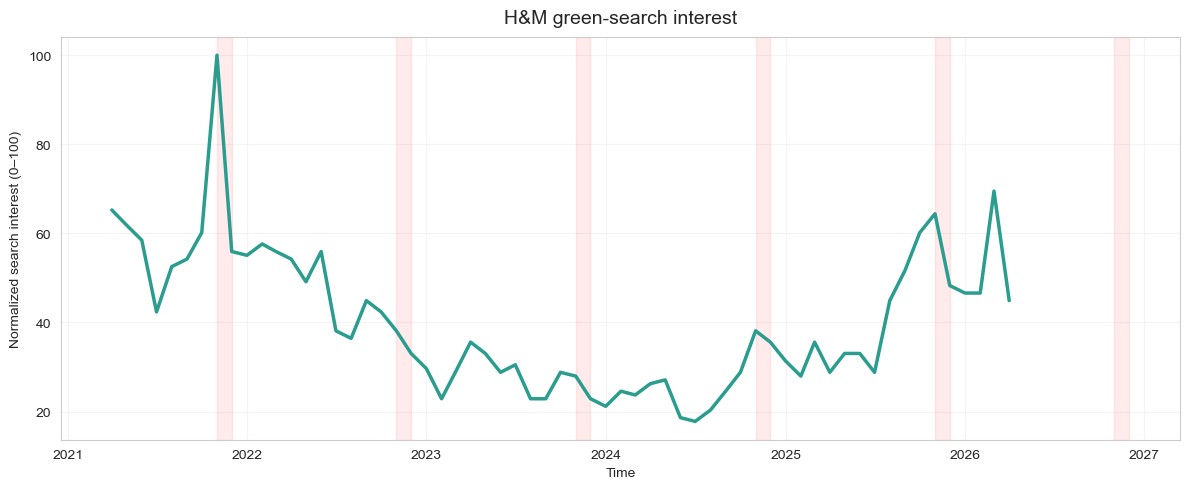

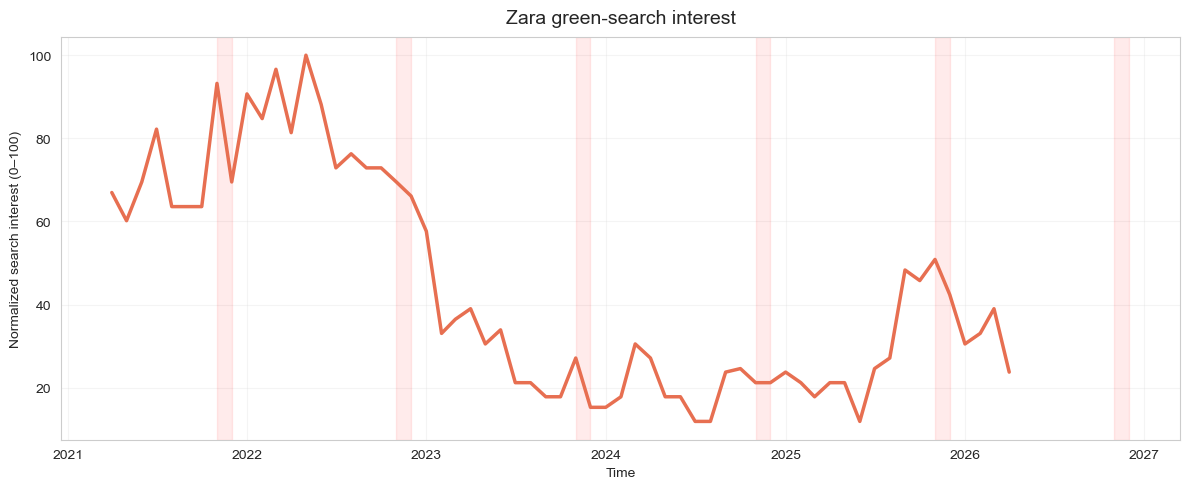

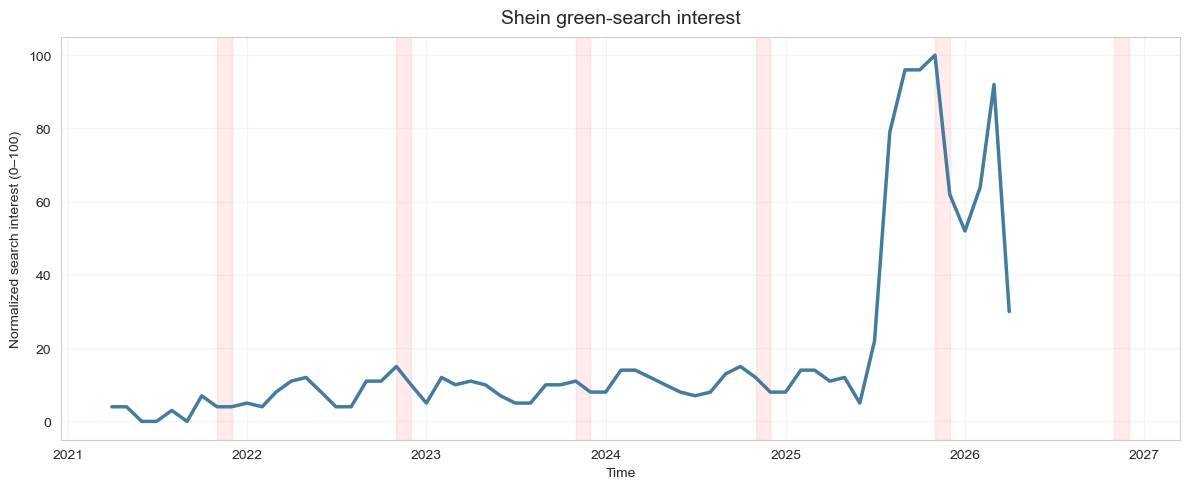

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Load files
hm = pd.read_csv("hm_trends.csv")
zara = pd.read_csv("zara_trends.csv")
shein = pd.read_csv("shein_trends.csv")

# Parse dates
for df in [hm, zara, shein]:
    df["Time"] = pd.to_datetime(df["Time"])
    df["year"] = df["Time"].dt.year
    df["month"] = df["Time"].dt.month

# Combine related terms
hm["combined"] = hm["H&M conscious"] + hm["H&M conscious collection"]
zara["combined"] = zara["Zara join life"] + zara["Zara sustainable clothing"]
shein["combined"] = shein.drop(columns=["Time", "year", "month"], errors="ignore").sum(axis=1)

# Normalize each brand separately
for df in [hm, zara, shein]:
    df["combined_norm"] = 100 * df["combined"] / df["combined"].max()

def plot_brand(df, title, color, filename):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["Time"], df["combined_norm"], color=color, linewidth=2.5)

    # Black Friday window: November
    for y in sorted(df["year"].unique()):
        ax.axvspan(pd.Timestamp(f"{y}-11-01"), pd.Timestamp(f"{y}-12-01"), color="red", alpha=0.08)

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("Time")
    ax.set_ylabel("Normalized search interest (0–100)")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

plot_brand(hm, "H&M green-search interest", "#2a9d8f", "hm_blackfriday_trend.png")
plot_brand(zara, "Zara green-search interest", "#e76f51", "zara_blackfriday_trend.png")
plot_brand(shein, "Shein green-search interest", "#457b9d", "shein_blackfriday_trend.png")

**Green search interest and Black Friday timing.**  
Across all three brands, the graphs show that search interest in green collections increases around Black Friday sale periods. This pattern suggests that the sustainability framing is being used as a marketing tool to attract consumers during major shopping events, rather than reflecting a stable or sustained interest in green clothing throughout the year. The pink vertical lines indicate Black Friday timing, making the seasonal alignment visible.